<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# kNN Classification in `scikit-learn` 

---

### About
Implement k-Nearest Neighbors (KNN) classification in Python using the `scikit-learn` library.

### Learning Objective
- Fit, evaluate, and generate predictions from a k-NN model in `scikit-learn`.


### Notebook Guide
- The Iris Dataset
- Data Cleaning
- EDA
   - Visualizing k-NN
   - Pairplot
- Modeling
   - Train/Test split
   - StandardScaler
   - Instantiate KNN
   - Cross validation
   - Model fitting and evaluation
   - Comparing Testing Accuracy With Null Accuracy - The Null Model (the baseline)
- TryIt with mobile data
   - Categorical features
   - Let's Get Modelin'
   - Create training and test sets
   - Standardize your variables
   - Train and evaluate your models
- Conclusions and Takeaways

# 1. Imports

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. The Iris Dataset


> The data set consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters. Based on the combination of these four features, Fisher developed a linear discriminant model to distinguish the species from each other. - [Wikipedia](https://en.wikipedia.org/wiki/Iris_flower_data_set)

<img src="../assets/iris_overview.png" style="width: 700px;">

In [6]:
# read in the iris data (./data/iris.csv)

iris = pd.read_csv('../data/iris.csv')
print("shape:", iris.shape)
iris.head()

shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 3. Data Cleaning

Let's see if our `DataFrame` requires any cleaning. In the cells below:
1. Check the `dtypes` to make sure every column is numerical
2. Check for null values

In [7]:
# check dtypes
iris.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [8]:
# check for missing values 
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

# 4. EDA
## Visualizing k-NN

Using `seaborn`, create a scatter plot using two features from your `DataFrame`: `'petal length (cm)'` and `'petal width (cm)'`. Each dot should be colored according to its species.

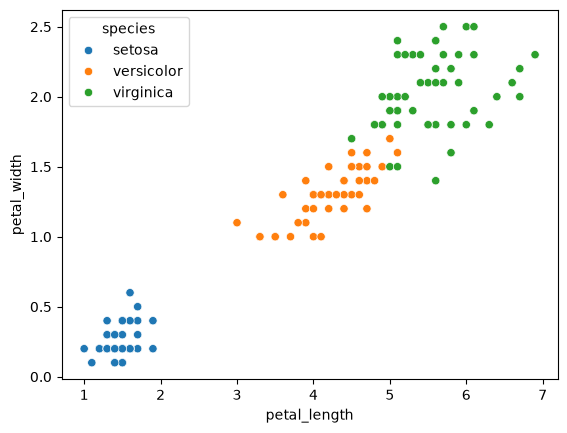

In [11]:
# create a scatter matrix of petal_length and petal_width and plot each species in a different color

sns.scatterplot(data = iris, x= 'petal_length', y = 'petal_width', hue='species');

## Pairplot

Let's expand on the scatter plot created in the previous step. We can use `seaborn`'s `.pairplot()` method to create scatter plots using all of our features.

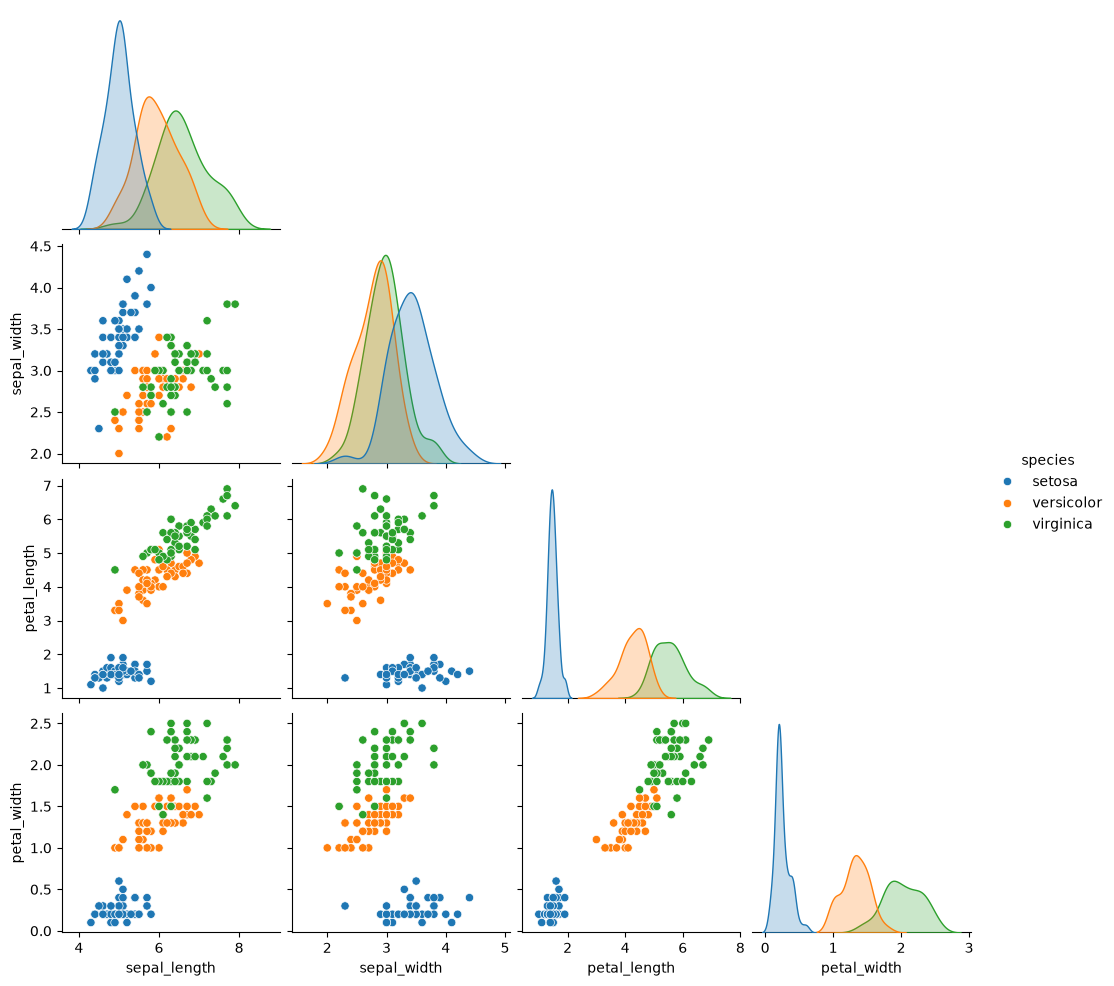

In [16]:
sns.pairplot(iris, hue='species', corner=True);

## Target Balance

Finally, let's check the target balance, i.e. the frequency of each target label

In [15]:
iris["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

_Our data is perfectly balanced, we will deal with inbalaced dataset later in the course_

# 5. Modeling

## Train/Test split

Use the `train_test_split` function to split your data into a training set and a holdout set.

In [17]:
# create X with your predictors and y with your outcome variable 
X = iris.drop('species', axis=1)
y = iris['species']

In [18]:
# split the data into training and test sets (80% training, 20% test)

# stratify=y keeps the same class distribution in both train and test sets.
# This is especially important when the target classes are imbalanced.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### `stratify=y` Parameter

The `stratify=y` parameter in `train_test_split` ensures that both training and test sets maintain the same **class distribution** as the original dataset.

#### What it does:
- Looks at the proportion of each class in your target variable `y`
- Splits the data while preserving these proportions in both train and test sets

#### Example:
If your original data has:
- 70% non-churn customers (0)
- 30% churn customers (1)

**With `stratify=y`:**
- Training set: ~70% non-churn, ~30% churn
- Test set: ~70% non-churn, ~30% churn

**Without stratification:**
- Training set might get: 80% non-churn, 20% churn
- Test set might get: 60% non-churn, 40% churn

#### Why it matters:
- **Reliable evaluation**: Your test results better reflect real-world performance
- **Critical for imbalanced datasets**: Especially important when one class is much more frequent than others

## `StandardScaler`

Because KNN is calculating the distance between neighbors, it's highly sensitive to the magnitude of your features.

Thus, in order for KNN to work properly, it's important to scale our data. In the cells below, create an instance of `StandardScaler` and use it to transform `X_train` and `X_test`.  

In [19]:
# call StandardScaler and fit on X_train
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test) 
# u don't want the model to take a look in ur X_test, so just transform it

## Instantiate KNN

For the `KNeighborsClassifier`, there a few important parameters to keep in mind:

1. `n_neighbors`: this is the "k" in k-NN. The best  will change from problem to problem, but the default is 5.
2. `weights`: The neighbors can all have an equal vote (`uniform`), or the closer points can have a higher weighted vote (`distance`).
3. `p`: The distance metric. The default is Euclidean distance (2). Changing it to 1 is setting the distance to Manhattan.


### What if we have an equal amount of votes per class, to predict a point?
- We can **weight the samples that are closer a point** to have more value in the voting process.
- Using an **odd quantity for $k$ can help** avoid classes having the same score towards predicted points.

In the cell below, instantiate a `knn` model using the default parameters.

In [22]:
knn = KNeighborsClassifier()

## Model fitting and evaluation

Now that we know what we can expect from our KNN model, let's 
1. fit the model to `X_train_scaled`, `y_train`
2. score it on `X_test_scaled`, `y_test`

In [28]:
knn.fit(X_train_sc, y_train)
knn.score(X_train_sc, y_train)

0.975

In [29]:
knn.score(X_test_sc, y_test)

0.9333333333333333

## Comparing Testing Accuracy With Null Accuracy - The Null Model (the baseline)

In classification tasks, Null Accuracy is the accuracy that can be achieved by **always predicting the most frequent class**. For example, if most players are Centers, we would always predict Center.

The null accuracy is a benchmark against which you may want to measure every classification model.

### Examine the class distribution from the training set

Remember that we are comparing KNN to this simpler model. So, we must find the most frequent class **of the training set**.

In [30]:
y_train.value_counts()

species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

In [31]:
most_freq_class = y_train.value_counts().index[0]

most_freq_class

'setosa'

### Compute null accuracy

In [32]:
y_test.value_counts()[most_freq_class] / len(y_test)

np.float64(0.3333333333333333)

### You can compute the Null / Baseline model using `DummyClassifier` in `scikit-learn`

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = ________(________=________)

dummy_clf.fit(________, ________)

dummy_clf.score(________, ________)

# 6. Try It
We have another data set on cell phone plan churning. A customer is said to "churn" when they drop their cell plan for another one. That is, churning means unsubscribing stops using the. We would like to predict if a customer is going to churn based on their plan usage. 
1. Read in the `./data/cell_phone_churn.csv` 
2. Check the data shape, check for missing, and complete other basic data checks 

In [3]:
churn = pd.read_csv('../data/cell_phone_churn.csv')
print("shape:", churn.shape)
churn.head()

shape: (3333, 20)


,state,account_length,area_code,intl_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
churn.isna().sum()

state             0
account_length    0
area_code         0
intl_plan         0
vmail_plan        0
vmail_message     0
day_mins          0
day_calls         0
day_charge        0
eve_mins          0
eve_calls         0
eve_charge        0
night_mins        0
night_calls       0
night_charge      0
intl_mins         0
intl_calls        0
intl_charge       0
custserv_calls    0
churn             0
dtype: int64

In [5]:
churn.dtypes

state                 str
account_length      int64
area_code           int64
intl_plan             str
vmail_plan            str
vmail_message       int64
day_mins          float64
day_calls           int64
day_charge        float64
eve_mins          float64
eve_calls           int64
eve_charge        float64
night_mins        float64
night_calls         int64
night_charge      float64
intl_mins         float64
intl_calls          int64
intl_charge       float64
custserv_calls      int64
churn                bool
dtype: object

## Categorical features 
This data set has a few categorical features. Does it make sense to include these features in a k-NN model? Why or why not? 
You can use categorical features if they are properly preprocessed but they can lead to high dimensionality, which could degrade the models performance.

For today, drop the categorical columns as for your first model trial.

As a second step, train your model with the categorical feature and check what happens to your score

## Let's Get Modelin'
Let's create our `X` and `y`. We'll use as much data as we can for `X`.

In [ ]:
# drop the columns that are not useful for modeling and create the X and y variables 


## Create training and test sets

## Standardize your variables 

##  Train and evaluate your models 
We let a default of $k$ = 5 earlier. Is that best? Try a few options 

In [ ]:
# Train with K = 3


In [ ]:
# run a knn for various values of k, and capture the resulting accuracy scores in a list

# Every loop iteration should
# 1. train a model with a specific k value
# 2. calculate the training score
# 3. calculate the testing score
# 4. create a dictionary storing K, train score and  test score
# 5. append the dictionary in the scores list

scores = []

for k in range(3, 32, 2):
    

In [ ]:
# plot your results for varying values of k

# 1. Convert the list of scores into a dictionary
# 2. In the same plot, graph a line chart showing the change of both scores against K


##  SCRETCH: Train another model, including the categorical features
_DON'T FORGET TO TRANSFORM YOUR CATEGORICAL FEATURES FIRST_


# 7. Conclusions and Takeaways

**What is kNN**
* k-nearest neighbors is a model that can be used for both regression and classification, but most commonly for classification.
* The "$k$" in kNN is what we'll come to know as a **tuning parameter** that can be adjusted to get a better model.

**What to pay attention to while training a kNN model?**
* kNN suffers from **"the curse of dimensionality"** - it gets more difficult to use and understand the more features (columns) we have. 
    - kNN is best when our data aren't too "wide".
* KNN can be quite sensitive to **outliers** because it relies directly on distances. 
    - An extreme observation can distort which points are considered nearest neighbors
* **Multicollinearity** can hurt KNN because several highly correlated features repeat similar information in the distance calculation.
    - This can make that information count more heavily than other features and distort which observations are considered the nearest neighbors.
* **Scaling** is important for KNN because features with larger numerical ranges can dominate the distance calculation and unfairly influence which points are considered nearest neighbors
* KNN does not assume a **linear relation** between features and target 
    - It learns from local neighborhoods instead.
    
**When to use kNN**
* When you don't have too many rows
* When you don't have too many columns
* When you don't have too many categorical features

**Why to use kNN then**
* To avoid high variance/overfitting